Import libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load data 

In [21]:
ratings = pd.read_csv('../data/ratings.csv')
movies = pd.read_csv('../data/movies.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


How many unique user and movies are available ?

In [22]:
ratings['userId'].nunique(), ratings['movieId'].nunique()

(610, 9724)

Total ratings 

In [23]:
len(ratings)

100836

Rating distrubution :
  Do users give mostly high ratings ?
  Is the dataset biased ?

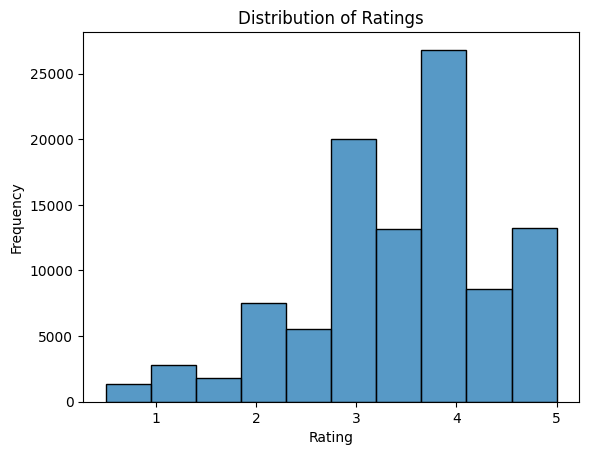

In [24]:
sns.histplot(ratings['rating'], bins=10)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency') 
plt.show()

Ratings per movie :
Check how the ratings are spread across movies 

Note: Movies with few movies are hard to recommend 

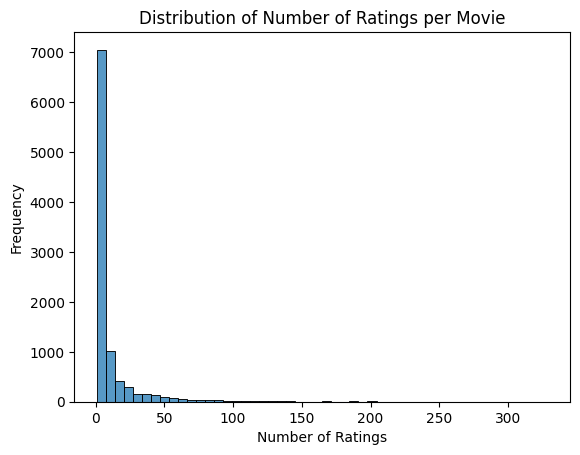

In [25]:
ratings_per_movie = ratings.groupby('movieId')['rating'].count()

sns.histplot(ratings_per_movie, bins=50)
plt.title('Distribution of Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')     
plt.show()

Combine movie names with ratings 

In [26]:
data=pd.merge(ratings, movies, on='movieId')
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Most popular movies 

In [27]:
popular_movies = data.groupby('title')['rating'].count().sort_values(ascending=False)

popular_movies.head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64

Frist recommendation : 
    Recommend most popular movies 
    Baseline model

Data splitting :
We spli the data into three sets here ,
Train set : To learn patterns 
Validation : To tune model parameters  (epochs,embedding size )
Test : For the final evaluation 

We do this , otherwise the recommendation models can easilt memorize user ratings (overfitting) 





In [28]:
from sklearn.model_selection import train_test_split

#Train and temp data 
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
#Validation and test data
validation_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(len(train_data), len(validation_data), len(test_data))

80668 10084 10084


Prepariing data for the model 
Extract three arrays from each dataset 
ML model will learn a function ,
 f(user_id , movie_id) → predicted_rating

 

In [29]:
train_user = train_data["userId"].values
train_movie = train_data["movieId"].values
train_rating = train_data["rating"].values

val_user = validation_data["userId"].values
val_movie = validation_data["movieId"].values
val_rating = validation_data["rating"].values

test_user = test_data["userId"].values
test_movie = test_data["movieId"].values
test_rating = test_data["rating"].values

Checking the Number of unique users and movies,
Embedding layer- needs to know how many IDs exist  

In [30]:
num_users = data["userId"].nunique()
num_movies = data["movieId"].nunique()

print(num_users, num_movies)

610 9724


Embeddings in recommendation systems , WHY? 

In a recommendation system, using just user IDs and movie IDs as input doesn’t tell the system anything about similarity or preferences. Instead, we use embeddings, which map each user and movie into a vector of numbers. These vectors capture hidden patterns, so similar users or similar movies have vectors that are close together. This helps the system predict what a user might like, even for movies they haven’t seen. Plain IDs or one hot encodings cannot do this because they are sparse and treat every user and movie as completely unrelated.


How ?
At the start, a recommendation system only has arrays of user IDs and movie IDs, along with data showing which users liked or watched which movies. The system assigns each user and movie a random vector at first. Then, by comparing predictions made from these vectors to the actual data, it adjusts the numbers over many iterations. In the end, each user and movie has an embedding vector that captures hidden patterns and similarities, allowing the system to make accurate recommendations even for movies the user hasn’t seen.

Factorization not needed - Tensorflow embeddings use onlyrated rows , model learns latent vectors automatically and we can add non linear dense layers .


Tensorflow model:



In [50]:
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode user and movie IDs

# Users
user_encoder = LabelEncoder()
train_user_enc = user_encoder.fit_transform(train_user)

# Movies
movie_encoder = LabelEncoder()
train_movie_enc = movie_encoder.fit_transform(train_movie)

# Filter validation data to include only users/movies seen in training
val_mask = np.isin(val_user, train_user) & np.isin(val_movie, train_movie)
val_user_enc = user_encoder.transform(val_user[val_mask])
val_movie_enc = movie_encoder.transform(val_movie[val_mask])
val_rating_enc = val_rating[val_mask]

#Define input layers for user and movie IDs 
#shape is (1,) because we are inputting one user ID and one movie ID at a time
user_input = layers.Input(shape=(1,))
movie_input = layers.Input(shape=(1,))

#Create embedding layers for users and movies
user_embedding = layers.Embedding(num_users, 32)(user_input)
movie_embedding = layers.Embedding(num_movies, 32)(movie_input)
#32 is embeddind dimension 
#Higher dimension- captures more patterns but needs more data

#Flatten the embeddings 
user_vec = layers.Flatten()(user_embedding)
movie_vec = layers.Flatten()(movie_embedding)

#Concatenate user and movie vectors (user-movie pair)
x = layers.Concatenate()([user_vec, movie_vec])

#Add dense layers (To learn none-linear relationships)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
output = layers.Dense(1)(x)

#Build the model
model = tf.keras.Model(
    inputs=[user_input, movie_input],
    outputs=output
)

#Compile the model
model.compile(
    optimizer="adam",
    loss="mse"
)
#MSE used - minimize (predicted_rating − true_rating)^2 -becasue we are predicting ratings

#Train the model
model.fit(
    [train_user_enc, train_movie_enc],
    train_rating,
    validation_data=([val_user_enc, val_movie_enc], val_rating_enc),
    epochs=10,
    batch_size=64
)

Epoch 1/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1011 - val_loss: 0.7870
Epoch 2/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7048 - val_loss: 0.7459
Epoch 3/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6567 - val_loss: 0.7424
Epoch 4/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6100 - val_loss: 0.7601
Epoch 5/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5566 - val_loss: 0.7628
Epoch 6/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4989 - val_loss: 0.8001
Epoch 7/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4417 - val_loss: 0.8154
Epoch 8/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3917 - val_loss: 0.8631
Epoch 9/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3511 - val_loss: 0.8769
Epoch 10/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3151 - val_loss: 0.8878


Note :

Problem:
 MOodel was crashing because the user and movie IDs in the dataset were too large & not sequential. Embedding layers can only look up IDs that are within the range of the embedding table (0 to number of users/movies − 1). For example, the training data had a user ID like 68157, but the embedding table only had 9725 rows. Also, some IDs in the validation set weren’t seen in training, which caused errors when trying to encode them.

How I fixed it:
Used LabelEncoder to map all user and movie IDs to a dense range starting from 0, so the embedding table could properly look them up. For validation, we kept only the users and movies that existed in the training set and encoded them the same way. This ensures all IDs are valid for the embedding layers, preventing crashes, while keeping the model structure and training logic unchanged.

Key takeawways from the first training :

Training loss is steadily decreasing → the model is memorizing the training ratings.

Validation loss started decreasing but then rises → the model is overfitting ; it doesn’t generalize to unseen ratings.

Why ? 
Embedding size too high → the model can “memorize” users and movies.
Dense layers too large → model can capture spurious patterns.
Not enough regularization → no constraints on weights.
Dataset sparsity → many users/movies have few ratings, so the model overfits easily

Fix ?
Reduce embedding size: from 32 → 16
Reduce dense layer size: 128 → 64, 64 → 32
Add Dropout: prevent overfitting

In [49]:
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping


# Encode user and movie IDs

# Users
user_encoder = LabelEncoder()
train_user_enc = user_encoder.fit_transform(train_user)

# Movies
movie_encoder = LabelEncoder()
train_movie_enc = movie_encoder.fit_transform(train_movie)

# Get number of users and movies
num_users = len(user_encoder.classes_)
num_movies = len(movie_encoder.classes_)

# Filter validation data to include only users/movies seen in training
val_mask = np.isin(val_user, train_user) & np.isin(val_movie, train_movie)
val_user_enc = user_encoder.transform(val_user[val_mask])
val_movie_enc = movie_encoder.transform(val_movie[val_mask])
val_rating_enc = val_rating[val_mask]

# Reshape inputs for model
train_user_enc = train_user_enc.reshape(-1, 1)
train_movie_enc = train_movie_enc.reshape(-1, 1)

val_user_enc = val_user_enc.reshape(-1, 1)
val_movie_enc = val_movie_enc.reshape(-1, 1)


#Define input layers for user and movie IDs 
#shape is (1,) because we are inputting one user ID and one movie ID at a time
user_input = layers.Input(shape=(1,))
movie_input = layers.Input(shape=(1,))

#Create embedding layers for users and movies
user_embedding = layers.Embedding(num_users, 32)(user_input)
movie_embedding = layers.Embedding(num_movies, 32)(movie_input)

#32 is embeddind dimension 
#Higher dimension- captures more patterns but needs more data

#Flatten the embeddings 
user_vec = layers.Flatten()(user_embedding)
movie_vec = layers.Flatten()(movie_embedding)

#Concatenate user and movie vectors (user-movie pair)
x = layers.Concatenate()([user_vec, movie_vec])

#Add dense layers (To learn none-linear relationships)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1)(x)

#Build the model
model = tf.keras.Model(
    inputs=[user_input, movie_input],
    outputs=output
)

#Compile the model
model.compile(
    optimizer="adam",
    loss="mse"
)
#MSE used - minimize (predicted_rating − true_rating)^2 -becasue we are predicting ratings
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

#Train the model
model.fit(
    [train_user_enc, train_movie_enc],
    train_rating,
    validation_data=([val_user_enc, val_movie_enc], val_rating_enc),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.3295 - val_loss: 0.7835
Epoch 2/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.8971 - val_loss: 0.7592
Epoch 3/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.8191 - val_loss: 0.7532
Epoch 4/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7611 - val_loss: 0.7411
Epoch 5/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7133 - val_loss: 0.7435
Epoch 6/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6741 - val_loss: 0.7432


conclusion from the above training : 
Training loss is steadily decreasing → the model is learning the training data.

Validation loss decreases initially and then stabilizes around 0.74 → the model is generalizing better than the previous run, and it hasn’t started overfitting yet.

Generating recommendations 
1. Picking a user - user_id=15

In [33]:
user_id = 15
#Get the movies the user has already rated 

user_rated_movies = train_data[train_data['userId'] == user_id]['movieId'].values
print(f"User {user_id} has rated movies: {user_rated_movies}")

User 15 has rated movies: [ 71264   8961  63859   1210    172   4018 166635    318    588  85414
   1200   1909  56174  97938    296    589  50872   4995   3555    858
  91500   1653 122904   3578  64614  33493 122886   4993   5971 120466
   5618 112852    355   3994   3535   5445   3949      1  79132   2959
   6502 152077   3499 122922   3617   4886 158872    596   7254 143385
   3753 115713 104841  60069 110102  48780   4022   2011   1198 122882
   4226    364 105504  84954    780  89745    260  48304  69757   4720
   2329 109487   8360   4370 152081  72998   1240   4306  70286   2571
   2085   2278  68954   5989   1270   1265 166528   2762 134853   6377
  71057     47  84152   8644    256   1196   5952   7438 122924  99114
   2012  91529 115149  48774   1347  96610   2001   3156  94864 134130
     44  68237 101864]


In [34]:
#Get all the unique movie IDs
all_movies = movies['movieId'].unique()
print(f"Total unique movies: {len(all_movies)}")

Total unique movies: 9742


In [35]:
#Find movies the user has not rated(We recommend movies the user hasnt interacted with)
unrated_movies = np.setdiff1d(all_movies, user_rated_movies)
print(f"User {user_id} has not rated movies: {unrated_movies}")
#Create input arrays for the model
user_array = np.full(len(unrated_movies), user_id)

User 15 has not rated movies: [     2      3      4 ... 193585 193587 193609]


In [ ]:
#Encode the user ID using the same encoder used during training
user_idx = user_encoder.transform([user_id])[0]

In [ ]:
#Encode the unrated movie IDs using the same encoder used during training
unrated_movies = np.array([m for m in unrated_movies if m in movie_encoder.classes_])

In [ ]:
#Transform the unrated movie IDs to their corresponding indices
unrated_movies_enc = movie_encoder.transform(unrated_movies)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [ ]:
#Create user array for prediction (same user ID repeated for each unrated movie)
user_array = np.full(len(unrated_movies_enc), user_idx)

In [ ]:
#Reshape for model input
user_array = user_array.reshape(-1, 1)
unrated_movies_enc = unrated_movies_enc.reshape(-1, 1)


In [ ]:
#Predict ratings for the unrated movies
predictions = model.predict([user_array, unrated_movies_enc])

278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step


In [ ]:
#Get the indices of the top predicted ratings
recommended_indices = np.argsort(predictions.flatten())[::-1]
top_k = 10

top_movie_indices = unrated_movies_enc[recommended_indices][:top_k]

In [ ]:
#Decode the movie indices back to movie IDs
top_movie_ids = movie_encoder.inverse_transform(top_movie_indices)
print(top_movie_ids)
#retrieve movie titles for the recommended movie IDs
recommended_movies = movies[movies['movieId'].isin(top_movie_ids)]
print(recommended_movies[['movieId', 'title']])

[  1096  41863   6440   1755   1799   3089  44195 117531   5782 176371]
      movieId                                              title
835      1096                             Sophie's Choice (1982)
1309     1755                               Shooting Fish (1997)
1330     1799                               Suicide Kings (1997)
2332     3089  Bicycle Thieves (a.k.a. The Bicycle Thief) (a....
4058     5782        Professional, The (Le professionnel) (1981)
4389     6440                                 Barton Fink (1991)
6086    41863    Three Burials of Melquiades Estrada, The (2006)
6153    44195                       Thank You for Smoking (2006)
8591   117531                                   Watermark (2014)
9604   176371                           Blade Runner 2049 (2017)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Evaluate Prediction Accuracy (RMSE / MAE)
RMSE: how far predicted ratings are from actual ratings  
MAE: average absolute error between predictions and real ratings




In [69]:
user_encoder.fit(train_data['userId'].values.ravel())
movie_encoder.fit(train_data['movieId'].values.ravel())

LabelEncoder()

In [72]:
test_data = test_data[test_data['movieId'].isin(movie_encoder.classes_)]

In [73]:
test_user_enc = user_encoder.transform(test_data['userId'].values.ravel())
test_movie_enc = movie_encoder.transform(test_data['movieId'].values.ravel())

In [75]:
# Filter unseen movies
test_data = test_data[test_data['movieId'].isin(movie_encoder.classes_)]

# Encode
test_user_enc = user_encoder.transform(test_data['userId'].values.ravel())
test_movie_enc = movie_encoder.transform(test_data['movieId'].values.ravel())
test_user_enc = test_user_enc.reshape(-1, 1)
test_movie_enc = test_movie_enc.reshape(-1, 1)

y_pred = model.predict([test_user_enc, test_movie_enc]).flatten()
# Targets
y_test = test_data['rating'].values

# Predict
y_pred = model.predict([test_user_enc, test_movie_enc]).flatten()

303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step


In [77]:
#Compare predictions with true ratings
y_test = test_data['rating'].values

#Calculate RMSE & MAE
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.9428073917812166
MAE: 0.7209996603825094


RMSE ≈ 0.94
MAE ≈ 0.72
What that means:
On average, predictions are off by about 0.7 rating points
RMSE being higher than MAE is expected (it penalizes larger errors more)

Conclusions -

Model is:
-working correctly
-learning meaningful patterns
-but still basic (not highly optimized)

How to improve ?
-Increase embedding capacity

| Metric      | Purpose                    |
| ----------- | -------------------------- |
| RMSE / MAE  | Rating accuracy            |
| Precision@K | Recommendation quality     |
| Recall@K    | Coverage of relevant items |


In [85]:
#Build relevance from test set

import numpy as np
from collections import defaultdict

# Define relevance threshold
relevance_threshold = 4.0

# Create ground truth: relevant movies per user
user_relevant_movies = defaultdict(set)

for _, row in test_data.iterrows():
    if row['rating'] >= relevance_threshold:
        user_relevant_movies[row['userId']].add(row['movieId'])

#Get all movies
all_movie_ids = movie_encoder.classes_

#Evaluation function
def precision_recall_at_k(model, user_encoder, movie_encoder, test_data, k=10):
    precision_list = []
    recall_list = []

    all_movie_ids = movie_encoder.classes_

    user_relevant_movies = defaultdict(set)
    for _, row in test_data.iterrows():
        if row['rating'] >= 4.0:
            user_relevant_movies[row['userId']].add(row['movieId'])

    for user_id in user_relevant_movies:

        relevant_movies = user_relevant_movies[user_id]

        # Encode user
        if user_id not in user_encoder.classes_:
            continue
        user_idx = user_encoder.transform([user_id])[0]

        # Movies not rated by user
        rated_movies = test_data[test_data['userId'] == user_id]['movieId'].values
        unrated_movies = np.setdiff1d(all_movie_ids, rated_movies)

        # Keep only known movies
        

        if len(unrated_movies) == 0:
            continue

        # Encode movies
        movie_indices = unrated_movies

        user_array = np.full(len(movie_indices), user_idx)

        # Reshape
        user_array = user_array.reshape(-1, 1)
        movie_indices = movie_indices.reshape(-1, 1)

        # Predict
        preds = model.predict([user_array, movie_indices], verbose=0).flatten()

        # Get top-K
        top_k_indices = np.argsort(preds)[::-1][:k]
        top_k_movies = unrated_movies[top_k_indices]

        # Compute metrics
        hits = len(set(top_k_movies) & relevant_movies)

        precision = hits / k
        recall = hits / len(relevant_movies) if len(relevant_movies) > 0 else 0

        precision_list.append(precision)
        recall_list.append(recall)

    return np.mean(precision_list), np.mean(recall_list)
#Run evaluation
precision, recall = precision_recall_at_k(model, user_encoder, movie_encoder, test_data, k=10)

print("Precision@10:", precision)
print("Recall@10:", recall)


InvalidArgumentError: Graph execution error:

Detected at node functional_5_1/embedding_11_1/GatherV2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\asyncio\base_events.py", line 641, in run_forever

  File "c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\asyncio\base_events.py", line 1986

In [84]:
print("Total relevant users:", len(user_relevant_movies))
for u in list(user_relevant_movies.keys())[:5]:
    print(u, user_relevant_movies[u])

print("Sample unrated movies:", unrated_movies[:10])

Total relevant users: 565
491 {31685, 49286, 30825, 88810, 2671, 40815, 50872, 7451}
603 {1289, 908, 2318, 1680, 1304, 1176, 2074, 2203, 2973, 931, 164, 1956, 1955, 426, 45, 4017, 307, 308, 1208, 1594, 1339, 3006, 2110, 3783, 968, 1097, 1484, 1997, 1228, 207, 1104, 4433, 4437, 1237, 4056, 3418, 4450, 1635, 2020, 3683, 1129, 235, 2155, 1904, 2932, 377, 506, 1916}
412 {1284, 933, 1221, 2712, 2542, 1276, 951, 1784, 1307, 2108, 1214}
292 {2115, 78499, 1221, 85414, 5445, 101864, 2376, 5418, 780, 3916, 1580, 80463, 2990, 2989, 33493, 1278}
1 {2116, 3639, 1927, 2987, 2797, 2991, 2353, 2193, 2387, 596, 1587, 2899, 151, 2329, 3578, 2459, 1500, 1214}
Sample unrated movies: [[ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]]
